#  <span style='color:DarkBlue'>ANALYSEZ DES DONNEES DE SYSTEMES EDUCATIFS. </span>
des données de la banque mondiale sur l'éducation

<div class="alert-info">
PLAN<br>
    
1. Présentation du projet <br>
2. Le jeu de données <br>
3. Séquence de filtrage des données <br>
4. Normalisation <br>
5. Méthode de classement des pays <br>
6. Géo localisation<br>    
7. Conclusion <br>
</div>

## <span style='color:Blue'>1. Présentation du projet.</span>


***Objectif du projet:***
Réaliser une analyse pré-exploratoire de données de systèmes éducatifs de la Banque Mondiale pour déterminer un projet d’expansion de notre start-up à l’international

Les informations à collecter de cette étude sont:

***Quels sont les pays avec un fort potentiel de clients pour nos services?***

***Dans quels pays l'entreprise doit-elle opérer en priorité?***



## <span style='color:Blue'>2. Le jeu de données. </span>

In [1]:
import pandas as pd

In [2]:
# Lecture des fichiers CSV pour remplir les DataFrame correspondants
country=pd.read_csv('EdStatsCountry.csv')
series=pd.read_csv('EdStatsSeries.csv')
country_series=pd.read_csv('EdStatsCountry-Series.csv')
data=pd.read_csv('EdStatsData.csv')
foot_note=pd.read_csv('EdStatsFootNote.csv')

### <span style='color:BlueViolet'>Vérification du fichier EdStatsCountry.csv</span>

In [3]:
# Affiche les 3 premières lignes du DataFrame 'country'
country.head(3)

,Country Code,Short Name,Table Name,Long Name,2-alpha code,Currency Unit,Special Notes,Region,Income Group,WB-2 code,...,IMF data dissemination standard,Latest population census,Latest household survey,Source of most recent Income and expenditure data,Vital registration complete,Latest agricultural census,Latest industrial data,Latest trade data,Latest water withdrawal data,Unnamed: 31
0,ABW,Aruba,Aruba,Aruba,AW,Aruban florin,SNA data for 2000-2011 are updated from offici...,Latin America & Caribbean,High income: nonOECD,AW,...,NaN,2010,NaN,NaN,Yes,NaN,NaN,2012.0,NaN,NaN
1,AFG,Afghanistan,Afghanistan,Islamic State of Afghanistan,AF,Afghan afghani,Fiscal year end: March 20; reporting period fo...,South Asia,Low income,AF,...,General Data Dissemination System (GDDS),1979,"Multiple Indicator Cluster Survey (MICS), 2010/11","Integrated household survey (IHS), 2008",NaN,2013/14,NaN,2012.0,2000,NaN
2,AGO,Angola,Angola,People's Republic of Angola,AO,Angolan kwanza,"April 2013 database update: Based on IMF data,...",Sub-Saharan Africa,Upper middle income,AO,...,General Data Dissemination System (GDDS),1970,"Malaria Indicator Survey (MIS), 2011","Integrated household survey (IHS), 2008",NaN,2015,NaN,NaN,2005,NaN


In [4]:
#permet de visualiser le nom, les types de données et les remplissages des colonnes
country.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 241 entries, 0 to 240
Data columns (total 32 columns):
 #   Column                                             Non-Null Count  Dtype  
---  ------                                             --------------  -----  
 0   Country Code                                       241 non-null    object 
 1   Short Name                                         241 non-null    object 
 2   Table Name                                         241 non-null    object 
 3   Long Name                                          241 non-null    object 
 4   2-alpha code                                       238 non-null    object 
 5   Currency Unit                                      215 non-null    object 
 6   Special Notes                                      145 non-null    object 
 7   Region                                             214 non-null    object 
 8   Income Group                                       214 non-null    object 
 9   WB-2 code 

In [5]:
country.describe() #resumé statistique (moyenne, la médiane, les quartiles, l'écart-type, et les valeurs minimales et maximales)

,National accounts reference year,Latest industrial data,Latest trade data,Unnamed: 31
count,32.00000,107.000000,185.000000,0.0
mean,2001.53125,2008.102804,2010.994595,NaN
std,5.24856,2.616834,2.569675,NaN
min,1987.00000,2000.000000,1995.000000,NaN
25%,1996.75000,2007.500000,2011.000000,NaN
50%,2002.00000,2009.000000,2012.000000,NaN
75%,2005.00000,2010.000000,2012.000000,NaN
max,2012.00000,2010.000000,2012.000000,NaN




<div class="alert-info">
Observations:
    
241 lignes, 32 colonnes,
le dataset assez bien rempli, contient des informations géographiques, économiques,  telles que le code ISO du pays, le nom long du pays, la région, le groupe de revenu...
</div>


### <span style='color:BlueViolet'> Vérification du fichier EdStatsSeries.csv</span> 

In [6]:
series.head(3)

,Series Code,Topic,Indicator Name,Short definition,Long definition,Unit of measure,Periodicity,Base Period,Other notes,Aggregation method,...,Notes from original source,General comments,Source,Statistical concept and methodology,Development relevance,Related source links,Other web links,Related indicators,License Type,Unnamed: 20
0,BAR.NOED.1519.FE.ZS,Attainment,Barro-Lee: Percentage of female population age...,Percentage of female population age 15-19 with...,Percentage of female population age 15-19 with...,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,Robert J. Barro and Jong-Wha Lee: http://www.b...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,BAR.NOED.1519.ZS,Attainment,Barro-Lee: Percentage of population age 15-19 ...,Percentage of population age 15-19 with no edu...,Percentage of population age 15-19 with no edu...,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,Robert J. Barro and Jong-Wha Lee: http://www.b...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,BAR.NOED.15UP.FE.ZS,Attainment,Barro-Lee: Percentage of female population age...,Percentage of female population age 15+ with n...,Percentage of female population age 15+ with n...,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,Robert J. Barro and Jong-Wha Lee: http://www.b...,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
series.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3665 entries, 0 to 3664
Data columns (total 21 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Series Code                          3665 non-null   object 
 1   Topic                                3665 non-null   object 
 2   Indicator Name                       3665 non-null   object 
 3   Short definition                     2156 non-null   object 
 4   Long definition                      3665 non-null   object 
 5   Unit of measure                      0 non-null      float64
 6   Periodicity                          99 non-null     object 
 7   Base Period                          314 non-null    object 
 8   Other notes                          552 non-null    object 
 9   Aggregation method                   47 non-null     object 
 10  Limitations and exceptions           14 non-null     object 
 11  Notes from original source    

<div class="alert-info">
Observations:

3665 lignes, 21 colonnes,le dataset EdStatsSeries  sont des données statiques détaillées sur les 3665 indicateurs regroupés par catégories, du code de série, du sujet, de la définition longue, de l’unité de mesure, de la périodicité et du concept et de la méthodologie statistiques...Les colonnes qui définissent l'indicateurs et la colonne Source ont un taux de remplissage élevé.
</div>


### <span style='color:BlueViolet'> Vérification du fichier Country-Series.csv </span>

In [8]:
country_series.head(3)

,CountryCode,SeriesCode,DESCRIPTION,Unnamed: 3
0,ABW,SP.POP.TOTL,Data sources : United Nations World Population...,NaN
1,ABW,SP.POP.GROW,Data sources: United Nations World Population ...,NaN
2,AFG,SP.POP.GROW,Data sources: United Nations World Population ...,NaN


In [9]:
country_series.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 613 entries, 0 to 612
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   CountryCode  613 non-null    object 
 1   SeriesCode   613 non-null    object 
 2   DESCRIPTION  613 non-null    object 
 3   Unnamed: 3   0 non-null      float64
dtypes: float64(1), object(3)
memory usage: 19.3+ KB


<div class="alert-info">
Observations:

613 lignes, 4 colonnes EdStatsCountry-Series.csv donne des indications entre un code de pays et ses codes indicateurs avec les références des sources. Mise à part une colonne ce Dataset est complet.
</div>

### <span style='color:BlueViolet'>Vérification du fichier FootNote.csv </span>

In [10]:
foot_note.head(3)

,CountryCode,SeriesCode,Year,DESCRIPTION,Unnamed: 4
0,ABW,SE.PRE.ENRL.FE,YR2001,Country estimation.,NaN
1,ABW,SE.TER.TCHR.FE,YR2005,Country estimation.,NaN
2,ABW,SE.PRE.TCHR.FE,YR2000,Country estimation.,NaN


In [11]:
foot_note.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 643638 entries, 0 to 643637
Data columns (total 5 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   CountryCode  643638 non-null  object 
 1   SeriesCode   643638 non-null  object 
 2   Year         643638 non-null  object 
 3   DESCRIPTION  643638 non-null  object 
 4   Unnamed: 4   0 non-null       float64
dtypes: float64(1), object(4)
memory usage: 24.6+ MB



<div class="alert-info">
Observations:
    
643638 lignes, 5 colonnes, EdStatsFootNote.csv contient des notes, dates ou description de mise à jour, sur certains indicateurs par pays et par années. 

</div>

### <span style='color:BlueViolet'>Vérification du fichier EdStatsData.csv</span>

In [12]:
data = pd.read_csv('EdStatsData.csv')

In [13]:
data.head(3)

,Country Name,Country Code,Indicator Name,Indicator Code,1970,1971,1972,1973,1974,1975,...,2060,2065,2070,2075,2080,2085,2090,2095,2100,Unnamed: 69
0,Arab World,ARB,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Arab World,ARB,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2.F,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Arab World,ARB,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2.GPI,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
data.tail(3)

,Country Name,Country Code,Indicator Name,Indicator Code,1970,1971,1972,1973,1974,1975,...,2060,2065,2070,2075,2080,2085,2090,2095,2100,Unnamed: 69
886927,Zimbabwe,ZWE,"Youth literacy rate, population 15-24 years, f...",SE.ADT.1524.LT.FE.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
886928,Zimbabwe,ZWE,"Youth literacy rate, population 15-24 years, g...",SE.ADT.1524.LT.FM.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
886929,Zimbabwe,ZWE,"Youth literacy rate, population 15-24 years, m...",SE.ADT.1524.LT.MA.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
data.isna().sum(axis=0) # identifier les valeurs manquantes

Country Name           0
Country Code           0
Indicator Name         0
Indicator Code         0
1970              814642
                   ...  
2085              835494
2090              835494
2095              835494
2100              835494
Unnamed: 69       886930
Length: 70, dtype: int64

In [16]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 886930 entries, 0 to 886929
Data columns (total 70 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Country Name    886930 non-null  object 
 1   Country Code    886930 non-null  object 
 2   Indicator Name  886930 non-null  object 
 3   Indicator Code  886930 non-null  object 
 4   1970            72288 non-null   float64
 5   1971            35537 non-null   float64
 6   1972            35619 non-null   float64
 7   1973            35545 non-null   float64
 8   1974            35730 non-null   float64
 9   1975            87306 non-null   float64
 10  1976            37483 non-null   float64
 11  1977            37574 non-null   float64
 12  1978            37576 non-null   float64
 13  1979            36809 non-null   float64
 14  1980            89122 non-null   float64
 15  1981            38777 non-null   float64
 16  1982            37511 non-null   float64
 17  1983      

In [17]:
data.shape #pour obtenir les dimensions

(886930, 70)

In [18]:
data.dtypes #pour obtenir les types de données de chaque colonne

Country Name       object
Country Code       object
Indicator Name     object
Indicator Code     object
1970              float64
                   ...   
2085              float64
2090              float64
2095              float64
2100              float64
Unnamed: 69       float64
Length: 70, dtype: object

In [19]:
data['Indicator Name'].unique() # pour obtenir les valeurs uniques de la colonne "Indicator Name"

array(['Adjusted net enrolment rate, lower secondary, both sexes (%)',
       'Adjusted net enrolment rate, lower secondary, female (%)',
       'Adjusted net enrolment rate, lower secondary, gender parity index (GPI)',
       ..., 'Youth literacy rate, population 15-24 years, female (%)',
       'Youth literacy rate, population 15-24 years, gender parity index (GPI)',
       'Youth literacy rate, population 15-24 years, male (%)'],
      dtype=object)

In [20]:
print("{}  indicateurs".format(data['Indicator Name'].nunique()))

3665  indicateurs


In [21]:
data.groupby('Country Name')['Indicator Code'].count()
print("{} indicateurs par pays".format(data.groupby('Country Name')['Indicator Code'].count()[0]))

3665 indicateurs par pays



<div class="alert-info">

Observation:
886 930 lignes, 70 colonnes, ce fichier contient les données relatives aux 3665 indicateurs, mesurées par pays et faux pays(groupement de pays, de revenus...), depuis 1970, ainsi que des projections jusqu'à 2100 . Le densité des données est uniforme  à partir de 2020 (51436 valeurs non-nulles par années). Il n'y a aucune donnée en 2018 et 2019, la quantité de données pour 2017 et 2016 est très faible comparées aux autres années. Avant 2016, la quantité de données est très hétérogène.Elle est beaucoup plus elevée entre 1990 et 2015 comparativement à la période 2020-2100. Nous remarquons un accroissement de données à chaque début de décennie.
</div>



<div class="alert alert-block alert-danger">


Une analyse plus approfondie de ce jeu de donnée via le site de la Worldbank (https://datacatalog.worldbank.org/dataset/education-statistics http://datatopics.worldbank.org/education/), le moteur de recherche Google et l'utilisation de Dataprep (bibliothèque Python open-source) pour automatiser l’analyse exploratoire des données, nous ont conduit à nous concentrer, uniquement, sur le fichier le plus important EdStatsData.csv. 
</div>

## <span style='color:Blue'>3. Séquence de Filtrage des données. </span>



### <span style='color:BlueViolet'> Supression des faux pays </span> 

In [22]:
#Afghanistan est le premier pays de la liste des pays classés alphabétiquement 
# Sélectionner les lignes dans data où 'Country Name' est égal à 'Afghanistan'
separation_1 = data[data['Country Name'].isin(['Afghanistan'])]
#séparation_1

In [23]:
#séparation_1= data[data['Country Name'] == 'Afghanistan']
#séparation_1

In [24]:
#conserver les pays
#Sélectionner les lignes à partir de l'index 91625 de  data
data_pays_select= data.loc[91625:,:]
#Afficher les dimensions de la DataFrame data_pays_select
data_pays_select.shape

(795305, 70)

In [25]:
data_pays_select.describe() #afficher les statistiques descriptives 

,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,...,2060,2065,2070,2075,2080,2085,2090,2095,2100,Unnamed: 69
count,6.858100e+04,3.171300e+04,3.162900e+04,3.143200e+04,3.158600e+04,8.307700e+04,3.321100e+04,3.328300e+04,3.327900e+04,3.247000e+04,...,51128.000000,51128.000000,51128.000000,51128.000000,51128.000000,51128.00000,51128.000000,51128.000000,51128.000000,0.0
mean,3.307705e+08,7.572854e+08,8.218597e+08,9.161492e+08,9.663843e+08,3.839944e+08,1.023072e+09,1.096568e+09,1.197306e+09,1.336740e+09,...,357.289588,359.411441,359.871759,358.876836,356.866900,354.21677,350.966970,346.988116,342.272427,NaN
std,2.289666e+10,3.501398e+10,3.718576e+10,3.987381e+10,4.019633e+10,2.513404e+10,4.208708e+10,4.439384e+10,4.759853e+10,5.084184e+10,...,5751.913931,5848.760371,5933.192043,5999.904457,6049.528174,6085.45823,6105.723882,6105.735658,6086.049083,NaN
min,-1.435564e+00,-1.594625e+00,-3.056522e+00,-4.032582e+00,-4.213563e+00,-3.658569e+00,-2.950945e+00,-3.174870e+00,-3.558749e+00,-2.973612e+00,...,-1.630000,-1.440000,-1.260000,-1.090000,-0.920000,-0.78000,-0.650000,-0.550000,-0.450000,NaN
25%,8.000000e-01,8.170800e+00,8.605000e+00,8.975150e+00,9.224063e+00,1.300000e+00,8.604725e+00,8.917840e+00,9.493350e+00,9.343963e+00,...,0.030000,0.030000,0.020000,0.020000,0.010000,0.01000,0.010000,0.010000,0.010000,NaN
50%,5.700000e+00,5.613826e+01,6.075474e+01,6.440604e+01,6.551884e+01,8.540000e+00,6.604468e+01,6.569330e+01,6.758112e+01,7.029190e+01,...,0.230000,0.230000,0.230000,0.230000,0.230000,0.23000,0.230000,0.220000,0.220000,NaN
75%,5.304000e+01,3.239300e+04,3.434700e+04,3.675200e+04,3.828750e+04,6.892000e+01,3.295000e+04,3.316200e+04,3.480900e+04,3.766075e+04,...,7.500000,7.405000,7.200000,7.000000,6.522500,5.90000,5.295000,4.500000,3.860000,NaN
max,4.779684e+12,4.937198e+12,5.197055e+12,5.490332e+12,5.461938e+12,5.451141e+12,5.744745e+12,6.009497e+12,6.343726e+12,6.545183e+12,...,644710.190000,675853.420000,700282.960000,717143.500000,727030.140000,731025.85000,728631.120000,719255.750000,703700.820000,NaN


In [26]:
#World est le dernier faux pays de la liste des faux pays classés alphabétiquement 
# Sélectionner les lignes de  data où 'Country Name' est égal à 'World'
séparation_2= data[data['Country Name'].isin(['World'])]
séparation_2

,Country Name,Country Code,Indicator Name,Indicator Code,1970,1971,1972,1973,1974,1975,...,2060,2065,2070,2075,2080,2085,2090,2095,2100,Unnamed: 69
87960,World,WLD,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
87961,World,WLD,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2.F,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
87962,World,WLD,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2.GPI,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
87963,World,WLD,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2.M,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
87964,World,WLD,"Adjusted net enrolment rate, primary, both sex...",SE.PRM.TENR,72.353142,72.258461,73.130409,75.258324,75.926712,77.053207,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91620,World,WLD,"Youth illiterate population, 15-24 years, male...",UIS.LP.AG15T24.M,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
91621,World,WLD,"Youth literacy rate, population 15-24 years, b...",SE.ADT.1524.LT.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
91622,World,WLD,"Youth literacy rate, population 15-24 years, f...",SE.ADT.1524.LT.FE.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
91623,World,WLD,"Youth literacy rate, population 15-24 years, g...",SE.ADT.1524.LT.FM.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [27]:
#On crée le dataframe contenant les données par faux pays
#Sélectionner les lignes jusqu'à l'index 91624 de  data
data_faux_pays_select = data.loc[:91624,:]
data_faux_pays_select.shape

(91625, 70)

### <span style='color:BlueViolet'>Choix de la période avec les données les plus pertinantes </span> 

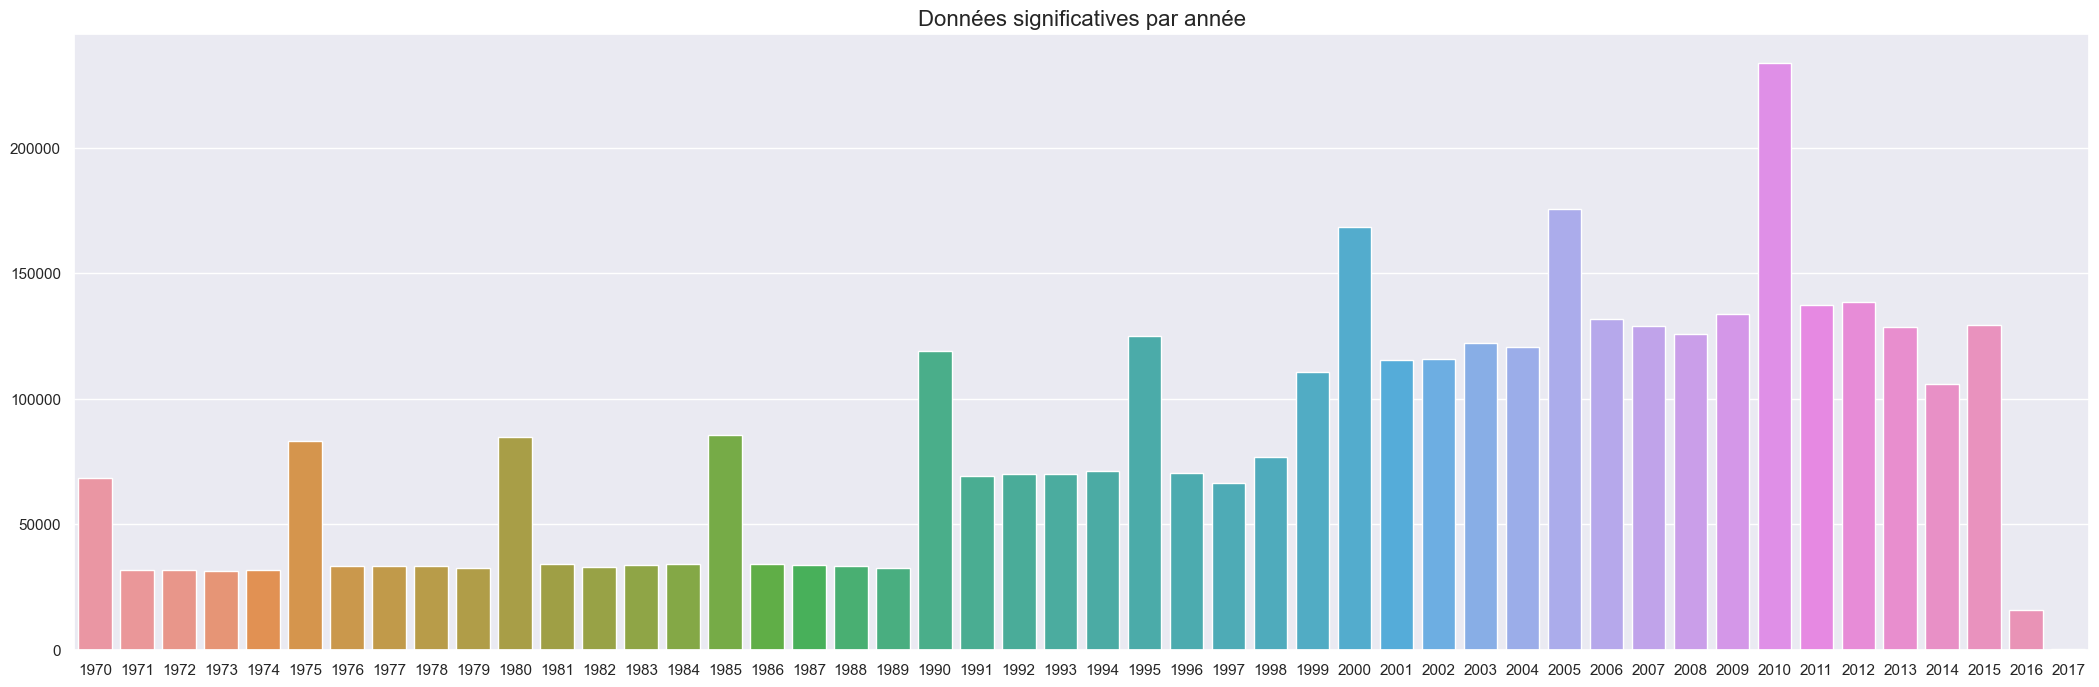

In [28]:
#choix de la période avec les données les plus pertinantes
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set(style="darkgrid")
plt.figure(figsize=(26,8))
plt.title('Données significatives par année',size=16)
# Compter le nombre de valeurs  manquantes pour chaque année
non_missing_counts = data_pays_select.shape[0] - data_pays_select[[str(annee) for annee in range(1970, 2018,1)]].isna().astype(int).sum()

# Afficher un graphique en barres indiquant le nombre de données significatives par année
sns.barplot(x=non_missing_counts.index, y=non_missing_counts.values)

plt.show()

<div class="alert-info">

nous remarquons que sur la période 2005->2015 la quantité des données est la plus important.
Nous prendrons la valeur moyenne de la période 2005-2015 comme référence pour notre étude
</div>

In [29]:
import warnings
warnings.filterwarnings('ignore')
# Créer des colonnes pour chaque décennie
# Ajouter une colonne pour chaque décennie représentant la moyenne des valeurs pour cette décennie
data_pays_select['1970s']=data_pays_select[[str(annee) for annee in range(1970,1980,1)]].mean(1)#Calcul la moyenne pour les années 1970-1979
data_pays_select['1980s'] = data_pays_select[[str(annee) for annee in range(1980,1990,1)]].mean(1)
data_pays_select['1990s'] = data[[str(annee) for annee in range(1990,2000,1)]].mean(1)
data_pays_select['2000s'] = data_pays_select[[str(annee) for annee in range(2000,2010,1)]].mean(1)
data_pays_select['2005-2015'] = data_pays_select[[str(annee) for annee in range(2005,2015,1)]].mean(1)#Calcul la moyenne pour les années 2005-2015
data_pays_select['2020s'] = data_pays_select[[str(annee) for annee in [2020,2025]]].mean(1)#Calcul la moyenne pour les années 2020 et 2025
data_pays_select['2030s'] = data_pays_select[[str(annee) for annee in [2030,2035]]].mean(1)
data_pays_select['2040s'] = data_pays_select[[str(annee) for annee in [2040,2045]]].mean(1)
data_pays_select['2050s'] = data_pays_select[[str(annee) for annee in [2050,2055]]].mean(1)
data_pays_select['2060s'] = data_pays_select[[str(annee) for annee in [2060,2065]]].mean(1)
data_pays_select['2070s'] = data_pays_select[[str(annee) for annee in [2070,2075]]].mean(1)
data_pays_select['2080s'] = data_pays_select[[str(annee) for annee in [2080,2085]]].mean(1)
data_pays_select['2090s'] = data_pays_select[[str(annee) for annee in [2090,2095]]].mean(1)
data_pays_select['2100s'] = data_pays_select[[str(2100)]].mean(1)
data_pays_select.head(5)

,Country Name,Country Code,Indicator Name,Indicator Code,1970,1971,1972,1973,1974,1975,...,2005-2015,2020s,2030s,2040s,2050s,2060s,2070s,2080s,2090s,2100s
91625,Afghanistan,AFG,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2,NaN,NaN,NaN,NaN,7.05911,NaN,...,42.041297,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
91626,Afghanistan,AFG,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2.F,NaN,NaN,NaN,NaN,2.53138,NaN,...,28.979300,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
91627,Afghanistan,AFG,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2.GPI,NaN,NaN,NaN,NaN,0.22154,NaN,...,0.514853,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
91628,Afghanistan,AFG,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2.M,NaN,NaN,NaN,NaN,11.42652,NaN,...,54.382287,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
91629,Afghanistan,AFG,"Adjusted net enrolment rate, primary, both sex...",SE.PRM.TENR,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### <span style='color:BlueViolet'> Données par decennie qui confirme notre choix </span>

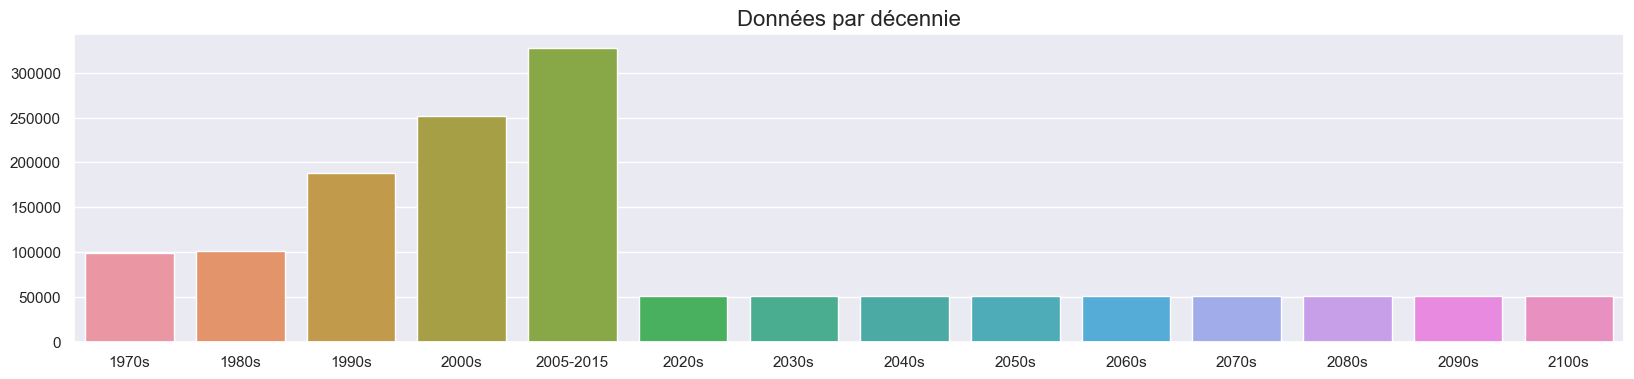

In [30]:
## afficher les donnée par decennie qui confirme notre choix
#créer une liste de noms de colonnes qui représentent différentes décennies
decade_columns=['1970s', '1980s','1990s', '2000s', '2005-2015', '2020s', '2030s', '2040s',
'2050s', '2060s', '2070s', '2080s', '2090s', '2100s']
sns.set(style="darkgrid") 
plt.figure(figsize=(20,4))
plt.title('Données par décennie',size=16)
plot=sns.barplot(y=data_pays_select.shape[0]-data_pays_select[decade_columns].isna().sum(), x=decade_columns ) 
plt.show()  


In [31]:
data_pays_select.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 795305 entries, 91625 to 886929
Data columns (total 84 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Country Name    795305 non-null  object 
 1   Country Code    795305 non-null  object 
 2   Indicator Name  795305 non-null  object 
 3   Indicator Code  795305 non-null  object 
 4   1970            68581 non-null   float64
 5   1971            31713 non-null   float64
 6   1972            31629 non-null   float64
 7   1973            31432 non-null   float64
 8   1974            31586 non-null   float64
 9   1975            83077 non-null   float64
 10  1976            33211 non-null   float64
 11  1977            33283 non-null   float64
 12  1978            33279 non-null   float64
 13  1979            32470 non-null   float64
 14  1980            84684 non-null   float64
 15  1981            34314 non-null   float64
 16  1982            33044 non-null   float64
 17  1983  

In [32]:
# sélectionner les colonnes à conserver
cols_to_keep = [ 'Country Name','Country Code','Indicator Name','Indicator Code','2005-2015']
# créer un masque de booléens indiquant si chaque colonne est à conserver ou non
mask = data_pays_select.columns.isin(cols_to_keep)
# garder uniquement les colonnes sélectionnées
data_pays_select= data_pays_select.loc[:, mask]
data_pays_select

,Country Name,Country Code,Indicator Name,Indicator Code,2005-2015
91625,Afghanistan,AFG,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2,42.041297
91626,Afghanistan,AFG,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2.F,28.979300
91627,Afghanistan,AFG,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2.GPI,0.514853
91628,Afghanistan,AFG,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2.M,54.382287
91629,Afghanistan,AFG,"Adjusted net enrolment rate, primary, both sex...",SE.PRM.TENR,NaN
...,...,...,...,...,...
886925,Zimbabwe,ZWE,"Youth illiterate population, 15-24 years, male...",UIS.LP.AG15T24.M,183071.500000
886926,Zimbabwe,ZWE,"Youth literacy rate, population 15-24 years, b...",SE.ADT.1524.LT.ZS,90.679410
886927,Zimbabwe,ZWE,"Youth literacy rate, population 15-24 years, f...",SE.ADT.1524.LT.FE.ZS,92.656455
886928,Zimbabwe,ZWE,"Youth literacy rate, population 15-24 years, g...",SE.ADT.1524.LT.FM.ZS,1.046085


### <span style='color:BlueViolet'>Indicateurs adéquats pour notre problematique</span>

In [33]:
#filtrer les indicateurs adéquats pour notre problematique 
indic_adhoc = ['IT.NET.USER.P2','NY.GDP.PCAP.PP.CD','SP.POP.1524.TO.UN','SE.TER.ENRL']

data_pays_select= data_pays_select[data_pays_select['Indicator Code'].isin(indic_adhoc)]
data_pays_select.head(9)

,Country Name,Country Code,Indicator Name,Indicator Code,2005-2015
92829,Afghanistan,AFG,"Enrolment in tertiary education, all programme...",SE.TER.ENRL,1.518543e+05
92872,Afghanistan,AFG,"GDP per capita, PPP (current international $)",NY.GDP.PCAP.PP.CD,1.488521e+03
93000,Afghanistan,AFG,Internet users (per 100 people),IT.NET.USER.P2,3.797582e+00
94107,Afghanistan,AFG,"Population, ages 15-24, total",SP.POP.1524.TO.UN,5.969358e+06
96494,Albania,ALB,"Enrolment in tertiary education, all programme...",SE.TER.ENRL,1.173502e+05
96537,Albania,ALB,"GDP per capita, PPP (current international $)",NY.GDP.PCAP.PP.CD,8.921302e+03
96665,Albania,ALB,Internet users (per 100 people),IT.NET.USER.P2,3.617060e+01
97772,Albania,ALB,"Population, ages 15-24, total",SP.POP.1524.TO.UN,5.958177e+05
100159,Algeria,DZA,"Enrolment in tertiary education, all programme...",SE.TER.ENRL,1.078053e+06


In [34]:
data_pays_select.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 868 entries, 92829 to 885747
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country Name    868 non-null    object 
 1   Country Code    868 non-null    object 
 2   Indicator Name  868 non-null    object 
 3   Indicator Code  868 non-null    object 
 4   2005-2015       769 non-null    float64
dtypes: float64(1), object(4)
memory usage: 40.7+ KB


In [35]:
warnings.filterwarnings('ignore')
#supprimer des colonnes
data_pays_select.drop(['Country Code', 'Indicator Code'], axis=1, inplace=True)
data_pays_select.head(9)

,Country Name,Indicator Name,2005-2015
92829,Afghanistan,"Enrolment in tertiary education, all programme...",1.518543e+05
92872,Afghanistan,"GDP per capita, PPP (current international $)",1.488521e+03
93000,Afghanistan,Internet users (per 100 people),3.797582e+00
94107,Afghanistan,"Population, ages 15-24, total",5.969358e+06
96494,Albania,"Enrolment in tertiary education, all programme...",1.173502e+05
96537,Albania,"GDP per capita, PPP (current international $)",8.921302e+03
96665,Albania,Internet users (per 100 people),3.617060e+01
97772,Albania,"Population, ages 15-24, total",5.958177e+05
100159,Algeria,"Enrolment in tertiary education, all programme...",1.078053e+06


#### <span style='color:BlueViolet'>*Pivot: les 4 valeurs de 'Indicator Name' deviennent des colonnes*</span>

In [36]:
#Les 4 valeurs de 'Indicator Name' deviennent des colonnes :

data_pays_select = data_pays_select.pivot_table(index= ["Country Name"],
                                      columns= ["Indicator Name"],
                                      values= ["2005-2015"])

data_pays_select = data_pays_select.reset_index()
data_pays_select.head(70)


Country Name  \
Indicator Name                     
0                    Afghanistan   
1                        Albania   
2                        Algeria   
3                 American Samoa   
4                        Andorra   
..                           ...   
65                       Finland   
66                        France   
67              French Polynesia   
68                         Gabon   
69                   Gambia, The   

                                                                          2005-2015  \
Indicator Name Enrolment in tertiary education, all programmes, both sexes (number)   
0                                                    1.518543e+05                     
1                                                    1.173502e+05                     
2                                                    1.078053e+06                     
3                                                    1.607000e+03                     
4                                                    4.548333e+02                     
..                                                            ...                     
65                                                   3.066367e+05                     
66                                                   2.243335e+06                     
67                                                            NaN                     
68                                                            NaN                     
69                                                   4.557000e+03                     

                                                              \
Indicator Name GDP per capita, PPP (current international $)   
0                                                1488.521343   
1                                                8921.302486   
2                                               12547.683912   
3                                                        NaN   
4                                                        NaN   
..                                                       ...   
65                                              38482.395465   
66                                              35805.976357   
67                                                       NaN   
68                                              15596.307123   
69                                               1518.739741   

                                                                              
Indicator Name Internet users (per 100 people) Population, ages 15-24, total  
0                                     3.797582                     5969357.5  
1                                    36.170596                      595817.7  
2                                    14.168112                     7177105.6  
3                                          NaN                           NaN  
4                                    74.431704                        8589.5  
..                                         ...                           ...  
65                                   84.460479                      653210.9  
66                                   70.029980                     7663754.7  
67                                   42.206678                           NaN  
68                                   15.675871                      288542.2  
69                                    9.183126                      344717.3  

[70 rows x 5 columns]

#### <span style='color:BlueViolet'>*Renommage des colonnes* </span>

In [37]:
# Renommer des colonnes

data_pays_select.columns = ['Pays','Inscription', 'PIB', 'NET.USER', 'Pop.Tot1524']

data_pays_select.set_index('Pays')
data_pays_select['Inscription'] = data_pays_select['Inscription'].fillna(1622693)
data_pays_select.head(70)

,Pays,Inscription,PIB,NET.USER,Pop.Tot1524
0,Afghanistan,1.518543e+05,1488.521343,3.797582,5969357.5
1,Albania,1.173502e+05,8921.302486,36.170596,595817.7
2,Algeria,1.078053e+06,12547.683912,14.168112,7177105.6
3,American Samoa,1.607000e+03,NaN,NaN,NaN
4,Andorra,4.548333e+02,NaN,74.431704,8589.5
...,...,...,...,...,...
65,Finland,3.066367e+05,38482.395465,84.460479,653210.9
66,France,2.243335e+06,35805.976357,70.029980,7663754.7
67,French Polynesia,1.622693e+06,NaN,42.206678,NaN
68,Gabon,1.622693e+06,15596.307123,15.675871,288542.2


In [38]:
data_pays_select.describe()

,Inscription,PIB,NET.USER,Pop.Tot1524
count,2.120000e+02,192.000000,204.000000,1.910000e+02
mean,1.050794e+06,17351.613693,32.856732,6.277149e+06
std,2.942541e+06,19858.710157,26.091617,2.364337e+07
min,3.500000e+00,604.662387,0.000000,2.778500e+03
25%,3.701014e+04,3281.922716,9.003418,3.132007e+05
50%,2.311611e+05,9803.946912,28.286995,1.232513e+06
75%,1.622693e+06,23245.709268,52.418095,4.494809e+06
max,2.962521e+07,118067.967253,93.023629,2.324822e+08


<AxesSubplot:>

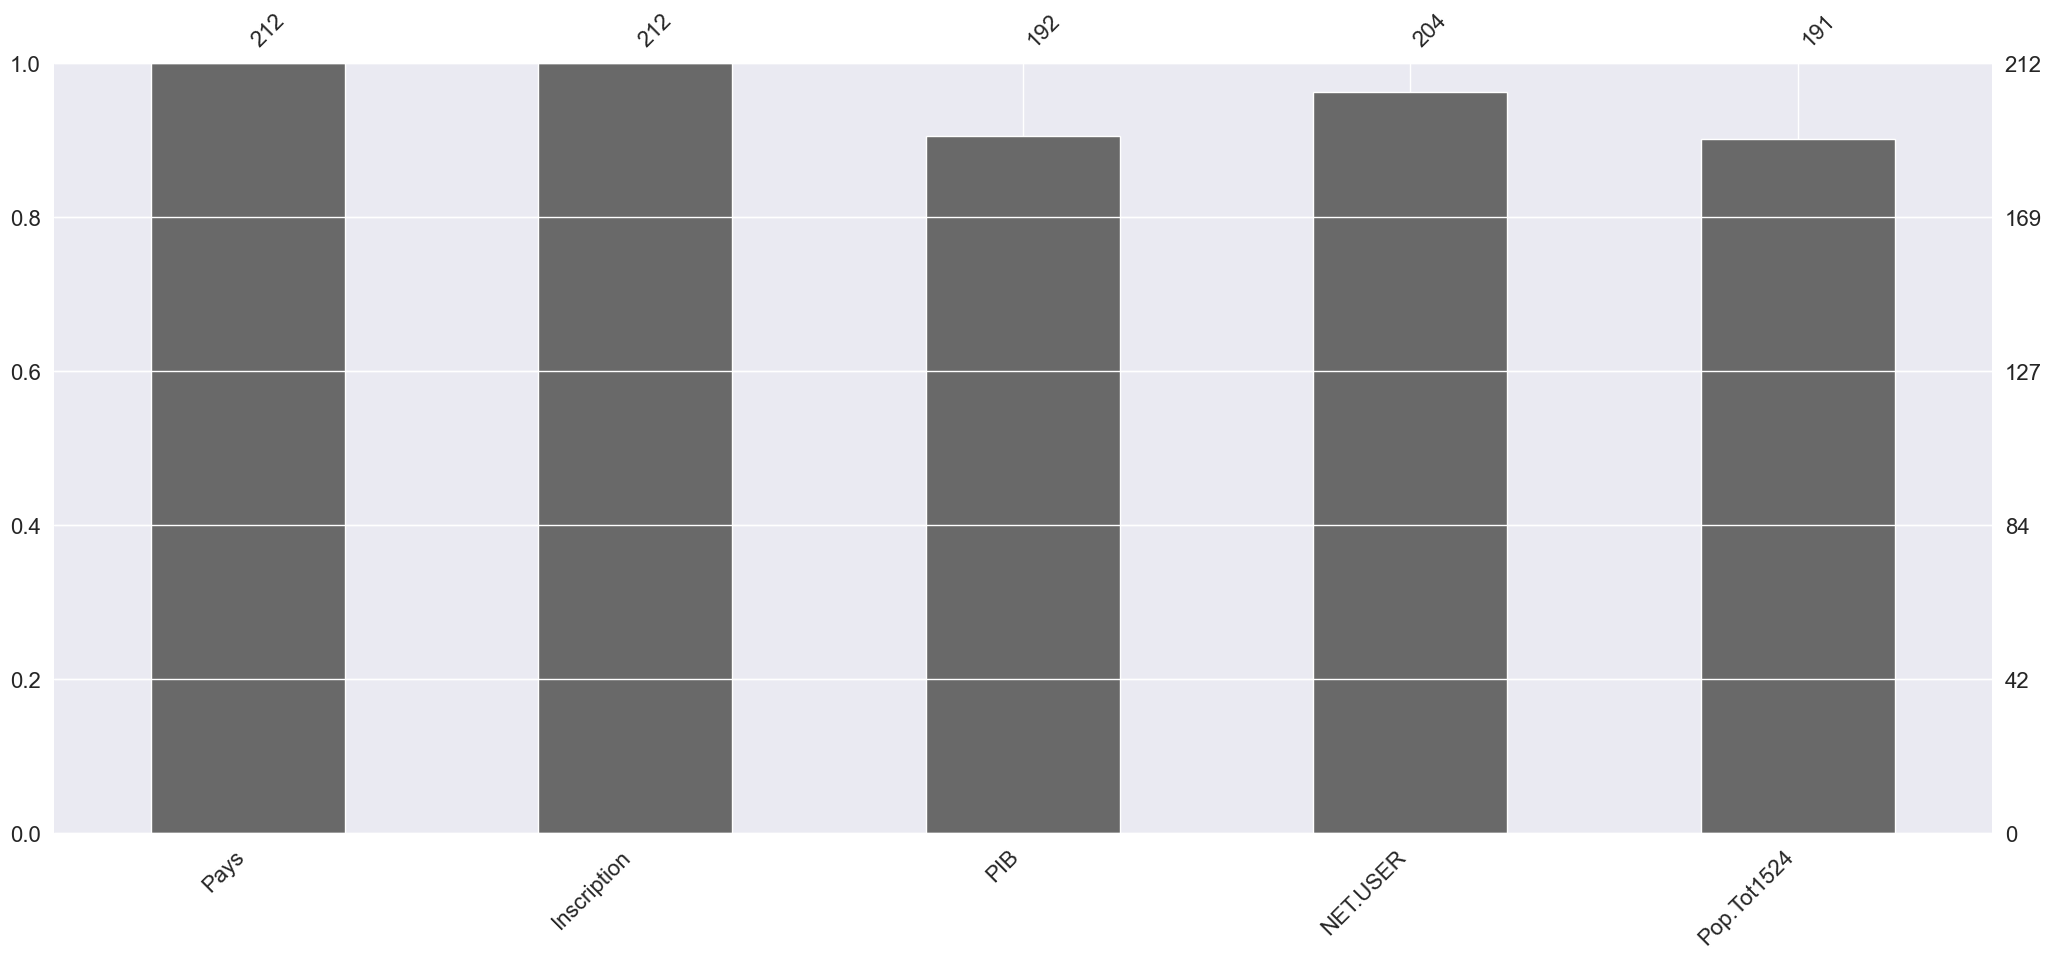

In [39]:
import missingno as msno
#visualiser les données manquantes 
msno.bar(data_pays_select)

In [40]:
data_pays_select.info

<bound method DataFrame.info of                       Pays   Inscription           PIB   NET.USER  Pop.Tot1524
0              Afghanistan  1.518543e+05   1488.521343   3.797582    5969357.5
1                  Albania  1.173502e+05   8921.302486  36.170596     595817.7
2                  Algeria  1.078053e+06  12547.683912  14.168112    7177105.6
3           American Samoa  1.607000e+03           NaN        NaN          NaN
4                  Andorra  4.548333e+02           NaN  74.431704       8589.5
..                     ...           ...           ...        ...          ...
207  Virgin Islands (U.S.)  2.488000e+03           NaN  33.951245          NaN
208     West Bank and Gaza  1.876362e+05           NaN  33.432900     866404.2
209            Yemen, Rep.  2.433257e+05   3970.633769  11.140792    5255140.2
210                 Zambia  5.621950e+04   3059.944302   9.310987    2697762.4
211               Zimbabwe  9.400575e+04   1585.039473   7.396474    3355468.1

[212 rows x 5 colum

### <span style='color:BlueViolet'>Selections des pays </span>

In [41]:
#Sélectionner les lignes où la valeur de PIB est supérieure ou égale à 32873 (80% PIB de la france PIB 41092*0.8=32873)
#et la valeur de Pop.Tot1524 est supérieure ou égale à 500000 dans le DataFrame data_pays_select

df_seuil_PIB_POP = data_pays_select.loc [((data_pays_select['PIB'] >=  32873) & (data_pays_select['Pop.Tot1524' ] >=500000))]

In [42]:
df_seuil_PIB_POP.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 22 entries, 10 to 201
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Pays         22 non-null     object 
 1   Inscription  22 non-null     float64
 2   PIB          22 non-null     float64
 3   NET.USER     22 non-null     float64
 4   Pop.Tot1524  22 non-null     float64
dtypes: float64(4), object(1)
memory usage: 1.0+ KB


#### <span style='color:Red'>*22 pays en liste*</span>

In [43]:
df_seuil_PIB_POP.head(30)

,Pays,Inscription,PIB,NET.USER,Pop.Tot1524
10,Australia,1.227505e+06,39703.799055,74.631119,2891825.9
11,Austria,3.283950e+05,42424.715781,73.284461,1001962.0
18,Belgium,4.374370e+05,39376.870780,72.048019,1259041.1
35,Canada,1.622693e+06,40557.236537,79.348000,4443212.6
52,Denmark,2.525646e+05,41899.681838,88.768973,657582.6
65,Finland,3.066367e+05,38482.395465,84.460479,653210.9
66,France,2.243335e+06,35805.976357,70.029980,7663754.7
71,Germany,2.846108e+06,39572.319563,78.901000,9393699.1
84,"Hong Kong SAR, China",2.419134e+05,46587.654773,68.976627,887453.6
91,Ireland,1.910398e+05,45234.143948,66.990599,606023.7


## <span style='color:Blue'>4. Normalisation</span>

In [44]:
from sklearn import preprocessing

In [45]:
#Cette fonction  effectue la normalisation sur les colonnes sélectionnées
def normalize_data(df):
    # Sélectionne les colonnes de l'index 1 à 5 à l'aide de la fonction .iloc[]
    df_ind = df.iloc[:, 1:5]
    # Arrondit les valeurs de ces colonnes à une décimale
    df_ind=df_ind.round(1)
    # Crée une instance de la classe MinMaxScaler de la bibliothèque sklearn preprocessing
    min_max_scaler = preprocessing.MinMaxScaler(feature_range =(0, 1))
    # Appelle la méthode fit_transform sur l'instance MinMaxScaler pour normaliser les données
    df_ind_apres_min_max_scaler = min_max_scaler.fit_transform(df_ind)
    # Les données normalisées obtenues sont à nouveau arrondies à une décimale
    df_ind_apres_min_max_scaler=df_ind_apres_min_max_scaler.round(1)
    # Retourne finalement les données normalisées
    return df_ind_apres_min_max_scaler

df_ind_apres_min_max_scaler = normalize_data(df_seuil_PIB_POP)
df_ind_apres_min_max_scaler

array([[0.1, 0.1, 0.7, 0.1],
       [0. , 0.2, 0.7, 0. ],
       [0. , 0.1, 0.7, 0. ],
       [0.1, 0.2, 0.8, 0.1],
       [0. , 0.2, 1. , 0. ],
       [0. , 0.1, 0.9, 0. ],
       [0.1, 0. , 0.6, 0.2],
       [0.1, 0.1, 0.8, 0.2],
       [0. , 0.3, 0.6, 0. ],
       [0. , 0.3, 0.6, 0. ],
       [0.1, 0. , 0.2, 0.1],
       [0.2, 0. , 0.8, 0.3],
       [0. , 0.3, 1. , 0. ],
       [0. , 0.7, 1. , 0. ],
       [0. , 0.2, 0. , 0. ],
       [0. , 0.3, 0.1, 0.1],
       [0. , 1. , 0.6, 0. ],
       [0. , 0.2, 1. , 0. ],
       [0. , 0.5, 0.8, 0. ],
       [0. , 0.9, 0.6, 0. ],
       [0.1, 0. , 0.8, 0.2],
       [1. , 0.4, 0.7, 1. ]])

## <span style='color:Blue'>5.Méthode de classement des pays</span>

### <span style='color:BlueViolet'> Etape 1 </span>

In [46]:
#Trier les données par ordre décroissant pour les colonnes "Inscription","PIB","NET.USER","Pop.Tot1524"
Inscription = df_seuil_PIB_POP.sort_values(by = 'Inscription', ascending=False)
PIB = df_seuil_PIB_POP.sort_values(by = 'PIB', ascending=False)
NET_USER = df_seuil_PIB_POP.sort_values(by = 'NET.USER', ascending=False)
Pop_Tot1524 = df_seuil_PIB_POP.sort_values(by = 'Pop.Tot1524', ascending=False)

#Récupérer les 10 premiers pays uniques pour les colonnes "Inscription","PIB","NET.USER","Pop.Tot1524"

list_Inscription = Inscription.head(10)['Pays'].unique()
list_PIB = PIB.head(10)['Pays'].unique()
list_NET_USER= NET_USER.head(10)['Pays'].unique()
list_Pop_Tot1524 = Pop_Tot1524.head(10)['Pays'].unique()


#Créer une liste de tuples comprenant les données et les poids pour chaque indicateur
listes = [  ("Inscription", list_Inscription, "poids_Inscription"),  ("PIB", list_PIB, "poids_PIB"),  ("NET.USER", list_NET_USER, "poids_NET_USER"), ("Pop.Tot1524", list_Pop_Tot1524, "PoidsPop_Tot1524")]
listes


[('Inscription',
  array(['United States', 'Japan', 'Germany', 'United Kingdom', 'France',
         'Italy', 'Canada', 'Australia', 'Saudi Arabia', 'Netherlands'],
        dtype=object),
  'poids_Inscription'),
 ('PIB',
  array(['Singapore', 'United Arab Emirates', 'Norway', 'Switzerland',
         'United States', 'Hong Kong SAR, China', 'Saudi Arabia', 'Ireland',
         'Netherlands', 'Austria'], dtype=object),
  'poids_PIB'),
 ('NET.USER',
  array(['Norway', 'Sweden', 'Netherlands', 'Denmark', 'Finland',
         'United Kingdom', 'Switzerland', 'Canada', 'Germany', 'Japan'],
        dtype=object),
  'poids_NET_USER'),
 ('Pop.Tot1524',
  array(['United States', 'Japan', 'Germany', 'United Kingdom', 'France',
         'Italy', 'Saudi Arabia', 'Canada', 'Australia', 'Netherlands'],
        dtype=object),
  'PoidsPop_Tot1524')]

#### <span style='color:Red'>*Mais quels pays choisir parmi ces listes de pays?*</span>

### <span style='color:BlueViolet'> Etape 2 </span>

In [47]:
#Initialiser une liste vide
dfs = []

#iterer  
for nom_ind, données, nom_poids in listes:
#Créer une liste de poids allant de la longueur de "données" à 0, décrémentant de 1 à chaque étape
    poids = list(range(len(données), 0, -1))
#Combiner les éléments de "données" et "poids" en paires    
    zipped = list(zip(données, poids))
#Créer un DataFrame pandas à partir de "zipped"    
    df = pd.DataFrame(zipped)
#Renommer les colonnes du DataFrame avec les noms "pays" et "nom_poids"    
    df.rename(columns={0: "pays", 1: nom_poids}, inplace=True)
#Ajouter le DataFrame à la liste "dfs"    
    dfs.append(df.pivot_table(columns="pays"))
dfs

[pays               Australia  Canada  France  Germany  Italy  Japan  \
 poids_Inscription          3       4       6        8      5      9   
 
 pays               Netherlands  Saudi Arabia  United Kingdom  United States  
 poids_Inscription            1             2               7             10  ,
 pays       Austria  Hong Kong SAR, China  Ireland  Netherlands  Norway  \
 poids_PIB        1                     5        3            2       8   
 
 pays       Saudi Arabia  Singapore  Switzerland  United Arab Emirates  \
 poids_PIB             4         10            7                     9   
 
 pays       United States  
 poids_PIB              6  ,
 pays            Canada  Denmark  Finland  Germany  Japan  Netherlands  Norway  \
 poids_NET_USER       3        7        6        2      1            8      10   
 
 pays            Sweden  Switzerland  United Kingdom  
 poids_NET_USER       9            4               5  ,
 pays              Australia  Canada  France  Germany  Ital

In [48]:
#Concaténer toutes les trames de données en un seul DataFrame et remplacer les valeurs manquantes par 0
df_total = pd.concat(dfs, axis=0)
df_total = df_total.fillna(0)
df_total

pays,Australia,Canada,France,Germany,Italy,Japan,Netherlands,Saudi Arabia,United Kingdom,United States,Austria,"Hong Kong SAR, China",Ireland,Norway,Singapore,Switzerland,United Arab Emirates,Denmark,Finland,Sweden
poids_Inscription,3.0,4.0,6.0,8.0,5.0,9.0,1,2.0,7.0,10.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
poids_PIB,0.0,0.0,0.0,0.0,0.0,0.0,2,4.0,0.0,6.0,1.0,5.0,3.0,8.0,10.0,7.0,9.0,0.0,0.0,0.0
poids_NET_USER,0.0,3.0,0.0,2.0,0.0,1.0,8,0.0,5.0,0.0,0.0,0.0,0.0,10.0,0.0,4.0,0.0,7.0,6.0,9.0
PoidsPop_Tot1524,2.0,3.0,6.0,8.0,5.0,9.0,1,4.0,7.0,10.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### <span style='color:BlueViolet'> Etape 3 </span>

In [49]:
import numpy as np
import itertools

# Convertir df_total en une matrice numpy pour faciliter les calculs
pays_matrix = df_total.to_numpy()


# Initialiser une liste vide pour stocker les poids
poids_ind = []

# Générer toutes les permutations possibles de poids [1, 2, 3, 4]
for i in list(itertools.permutations([1, 2, 3,4])):
# Convertir les permutations en tableau numpy    
    array_i= np.array(i)
    # Ajouter chaque combinaison de poids à la liste poids_ind
    poids_ind.append(array_i)
poids_ind   

[array([1, 2, 3, 4]),
 array([1, 2, 4, 3]),
 array([1, 3, 2, 4]),
 array([1, 3, 4, 2]),
 array([1, 4, 2, 3]),
 array([1, 4, 3, 2]),
 array([2, 1, 3, 4]),
 array([2, 1, 4, 3]),
 array([2, 3, 1, 4]),
 array([2, 3, 4, 1]),
 array([2, 4, 1, 3]),
 array([2, 4, 3, 1]),
 array([3, 1, 2, 4]),
 array([3, 1, 4, 2]),
 array([3, 2, 1, 4]),
 array([3, 2, 4, 1]),
 array([3, 4, 1, 2]),
 array([3, 4, 2, 1]),
 array([4, 1, 2, 3]),
 array([4, 1, 3, 2]),
 array([4, 2, 1, 3]),
 array([4, 2, 3, 1]),
 array([4, 3, 1, 2]),
 array([4, 3, 2, 1])]

In [50]:

# Initialiser une liste vide pour stocker les résultats
resultat = []

# Boucler sur les poids pour effectuer le produit matriciel entre les poids et la matrice de pays

for i in poids_ind:
    # Calculer le produit matriciel
    produit = i.dot(pays_matrix)
    # Ajouter le produit matriciel à la liste des résultats
    resultat.append(produit)

# Afficher les résultats
resultat


[array([11., 25., 30., 46., 25., 48., 33., 26., 50., 62.,  2., 10.,  6.,
        46., 20., 26., 18., 21., 18., 27.]),
 array([ 9., 25., 24., 40., 20., 40., 40., 22., 48., 52.,  2., 10.,  6.,
        56., 20., 30., 18., 28., 24., 36.]),
 array([11., 22., 30., 44., 25., 47., 27., 30., 45., 68.,  3., 15.,  9.,
        44., 30., 29., 27., 14., 12., 18.]),
 array([ 7., 22., 18., 32., 15., 31., 41., 22., 41., 48.,  3., 15.,  9.,
        64., 30., 37., 27., 28., 24., 36.]),
 array([ 9., 19., 24., 36., 20., 38., 28., 30., 38., 64.,  4., 20., 12.,
        52., 40., 36., 36., 14., 12., 18.]),
 array([ 7., 19., 18., 30., 15., 30., 35., 26., 36., 54.,  4., 20., 12.,
        62., 40., 40., 36., 21., 18., 27.]),
 array([14., 29., 36., 54., 30., 57., 32., 24., 57., 66.,  1.,  5.,  3.,
        38., 10., 19.,  9., 21., 18., 27.]),
 array([12., 29., 30., 48., 25., 49., 39., 20., 55., 56.,  1.,  5.,  3.,
        48., 10., 23.,  9., 28., 24., 36.]),
 array([14., 23., 36., 50., 30., 55., 20., 32., 47., 78.

### <span style='color:BlueViolet'> Etape 4 </span>

In [51]:
# Création du dataFrame Grille_notation pour stocker les résultats de notation
Grille_notation=pd.DataFrame(resultat, columns=['Australia','Canada','France','Germany','Italy','Japan','Netherlands',
                                             'Saudi Arabia','United Kingdom','United States','Austria','Hong Kong SAR China',
                                             'Ireland','Norway','Singapore','Switzerland','United Arab Emirates','Denmark',
                                             'Finland','Sweden'])
Grille_notation

,Australia,Canada,France,Germany,Italy,Japan,Netherlands,Saudi Arabia,United Kingdom,United States,Austria,Hong Kong SAR China,Ireland,Norway,Singapore,Switzerland,United Arab Emirates,Denmark,Finland,Sweden
0,11.0,25.0,30.0,46.0,25.0,48.0,33.0,26.0,50.0,62.0,2.0,10.0,6.0,46.0,20.0,26.0,18.0,21.0,18.0,27.0
1,9.0,25.0,24.0,40.0,20.0,40.0,40.0,22.0,48.0,52.0,2.0,10.0,6.0,56.0,20.0,30.0,18.0,28.0,24.0,36.0
2,11.0,22.0,30.0,44.0,25.0,47.0,27.0,30.0,45.0,68.0,3.0,15.0,9.0,44.0,30.0,29.0,27.0,14.0,12.0,18.0
3,7.0,22.0,18.0,32.0,15.0,31.0,41.0,22.0,41.0,48.0,3.0,15.0,9.0,64.0,30.0,37.0,27.0,28.0,24.0,36.0
4,9.0,19.0,24.0,36.0,20.0,38.0,28.0,30.0,38.0,64.0,4.0,20.0,12.0,52.0,40.0,36.0,36.0,14.0,12.0,18.0
5,7.0,19.0,18.0,30.0,15.0,30.0,35.0,26.0,36.0,54.0,4.0,20.0,12.0,62.0,40.0,40.0,36.0,21.0,18.0,27.0
6,14.0,29.0,36.0,54.0,30.0,57.0,32.0,24.0,57.0,66.0,1.0,5.0,3.0,38.0,10.0,19.0,9.0,21.0,18.0,27.0
7,12.0,29.0,30.0,48.0,25.0,49.0,39.0,20.0,55.0,56.0,1.0,5.0,3.0,48.0,10.0,23.0,9.0,28.0,24.0,36.0
8,14.0,23.0,36.0,50.0,30.0,55.0,20.0,32.0,47.0,78.0,3.0,15.0,9.0,34.0,30.0,25.0,27.0,7.0,6.0,9.0
9,8.0,23.0,18.0,32.0,15.0,31.0,41.0,20.0,41.0,48.0,3.0,15.0,9.0,64.0,30.0,37.0,27.0,28.0,24.0,36.0


In [52]:
#en sommant les point de tout les classements nous obtenons une sorte de classement moyens de tous les pays

# Calcule la moyenne des valeurs pour chaque colonne dans Grille_notation,
#trier les valeurs par ordre décroissant,selectionner les 10 premières valeurs
classement=Grille_notation.mean(axis=0).sort_values(ascending=False).head(10)
# Convertir  en DataFrame
classement= pd.DataFrame(classement)
# Réinitialiser l'index,  renommer les colonnes en 'pays' et'note_finale'
classement=classement.reset_index().rename(columns={'index':'pays', 0: 'note_finale'})
classement

,pays,note_finale
0,United States,65.0
1,Japan,47.5
2,United Kingdom,47.5
3,Germany,45.0
4,Norway,45.0
5,France,30.0
6,Netherlands,30.0
7,Switzerland,27.5
8,Italy,25.0
9,Saudi Arabia,25.0


## <span style='color:Blue'>6.Géo localisation</span>


In [53]:
import matplotlib.pyplot as plt
# Importation de la bibliothèque folium pour la création de cartes interactives
import folium
# Importation de l'élément Figure de la bibliothèque branca
from branca.element import Figure

#Top 5 des pays par indicateur
fig=Figure(width=900,height=500)

# Création d'une carte centrée  avec un zoom de départ de 2
m=folium.Map(location=[38.9423133,34.9165444], tiles='cartodbpositron',zoom_start=2)
# Ajout de la carte à l'objet Figure
fig.add_child(m)



#Norway 64.58301349999999,17.86410976037601
folium.Marker(location=[64.5731537, 11.5280364],
              tooltip='<strong>en n°5 Norway</strong>',
              icon=folium.Icon(color='red',icon='info-sign')).add_to(m)

#Germany 51.1657065,10.452764000000002 
folium.Marker(location=[51.1657065, 10.452764000000002],
             tooltip='<strong>en n°4 Germany</strong>',
              icon=folium.Icon(color='red',icon='info-sign')).add_to(m)

#United Kingdom 54.633221000000006,-3.432277499999998
folium.Marker(location=[54.633221000000006, -3.432277499999998],
              tooltip='<strong>en n°3 United Kingdom</strong>',
              icon=folium.Icon(color='red',icon='info-sign')).add_to(m)


#United States 36.966428,-95.844032
folium.Marker(location=[36.966428, -95.844032],
              tooltip='<strong>en n°1 United States</strong>',
              icon=folium.Icon(color='red',icon='info-sign')).add_to(m)

#Japan 34.886306,134.379711
folium.Marker(location=[34.886306, 134.379711],
              tooltip='<strong>en n°2 Japan</strong>',
              icon=folium.Icon(color='red',icon='info-sign')).add_to(m)


# Affichage de la carte avec les marqueurs ajoutés
m

## <span style='color:Blue'>7. Conclusion.</span>

In [54]:
#Top 5 des pays par indicateur
classement.head(5)

,pays,note_finale
0,United States,65.0
1,Japan,47.5
2,United Kingdom,47.5
3,Germany,45.0
4,Norway,45.0
